In [99]:
import os
import TimeTagger
import matplotlib
import numpy as np
from datetime import datetime
from matplotlib import pyplot as plt

matplotlib.rcParams.update(
        {"font.family": "STIXGeneral",
         "xtick.labelsize": 20,
         "xtick.direction": "in",
         "xtick.major.pad": 8,
         "xtick.top": True,
         "ytick.labelsize": 20,
         "ytick.direction": "in",
         "ytick.right": True,
         "axes.labelsize": 20,
         "axes.labelpad": 10,
         "axes.grid": True
    }
)

# Start_time1 = 0.0
# End_time1 = 2
# Start_time2 = 13.0
# End_time2 = 15
# Start_time3 = 25.0
# End_time3 = 27
# Start_time4 = 37.0
# End_time4 = 39
# Start_time5 = 49.0
# End_time5 = 51
# Start_time6 = 60.5
# End_time6 = 62.5
# Start_time7 = 72.0
# End_time7 = 74
# Start_time8 = 85.0
# End_time8 = 87.0
# Start_time9 = 97.5
# End_time9 = 99.5

Start_time1 = 0.0
End_time1 = 2
Start_time2 = 13.0
End_time2 = 15
Start_time3 = 25.0
End_time3 = 27
Start_time4 = 37.0
End_time4 = 39
Start_time5 = 49.0
End_time5 = 51
Start_time6 = 60.5
End_time6 = 62.5
Start_time7 = 72.0
End_time7 = 74
Start_time8 = 85.0
End_time8 = 87.0
Start_time9 = 97.5
End_time9 = 99.5

# Number of bins and binwidth for correlation measurement
number = 750
binwidth_corr = 200 * 1e3

# Number of bins and binwidth for histogram measurement
number_bins = 230 * 2
binwidth_hist = 250 * 1e3

# Time filtering window length
time_filtering = 1 * 1e6

# The defination of all channels
trigger_channel = 2
PMT_channel1 = 1
PMT_channel2 = 3

# g2_data_path
g2_data_path = "D:/Data Storage/Multiplexing/g2_data/"

In [148]:
all_raw_data = ["filewriterDate 2024-01-13, Time 12-27_9_ions.1.ttbin",
                "filewriterDate 2024-01-13, Time 20-36_9_ions.1.ttbin",
                "filewriterDate 2024-01-13, Time 19-47_9_ions.1.ttbin",
                "filewriterDate 2024-01-13, Time 19-29_9_ions.1.ttbin",
                "filewriterDate 2024-01-13, Time 17-12_9_ions.1.ttbin",
                "filewriterDate 2024-01-13, Time 15-33_9_ions.1.ttbin"]

# all_raw_data = ["filewriterDate 2024-01-13, Time 15-2_9_ions.1.ttbin"]

raw_data = ["filewriterDate 2024-01-13, Time 12-27_9_ions.1.ttbin",
            "filewriterDate 2024-01-13, Time 13-5_9_ions.1.ttbin",
            "filewriterDate 2024-01-13, Time 13-40_9_ions.1.ttbin",
            "filewriterDate 2024-01-13, Time 15-2_9_ions.1.ttbin",
            "filewriterDate 2024-01-13, Time 20-36_9_ions.1.ttbin",
            "filewriterDate 2024-01-13, Time 19-47_9_ions.1.ttbin",
            "filewriterDate 2024-01-13, Time 19-29_9_ions.1.ttbin",
            "filewriterDate 2024-01-13, Time 17-12_9_ions.1.ttbin"]

Date 2024-01-15, Time 12-1
Date 2024-01-15, Time 12-1
Date 2024-01-15, Time 12-1
Date 2024-01-15, Time 12-1
Date 2024-01-15, Time 12-1
Date 2024-01-15, Time 12-1


<Figure size 640x480 with 0 Axes>

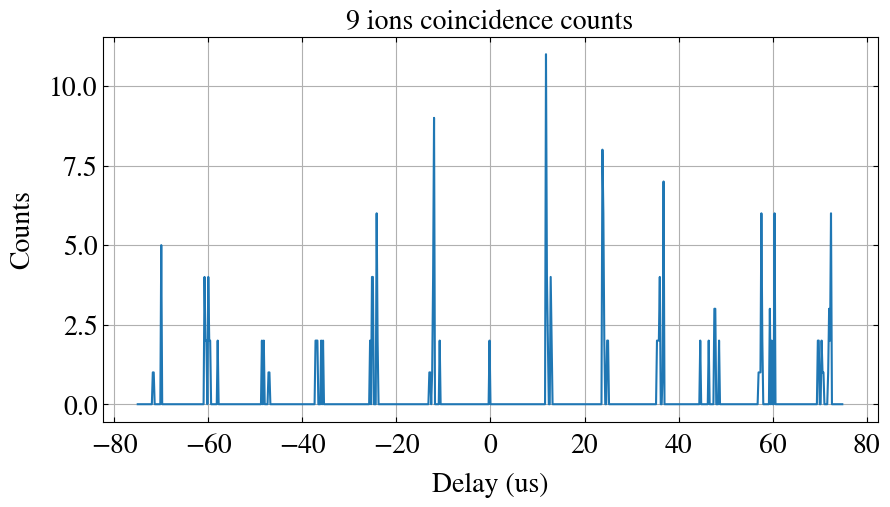

Start time = 0.0 us
End time = 2.0 us
Start time = 13.0 us
End time = 15.0 us
Start time = 25.0 us
End time = 27.0 us
Start time = 37.0 us
End time = 39.0 us
Start time = 49.0 us
End time = 51.0 us
Start time = 60.5 us
End time = 62.5 us
Start time = 72.0 us
End time = 74.0 us
Start time = 85.0 us
End time = 87.0 us
Start time = 97.5 us
End time = 99.5 us


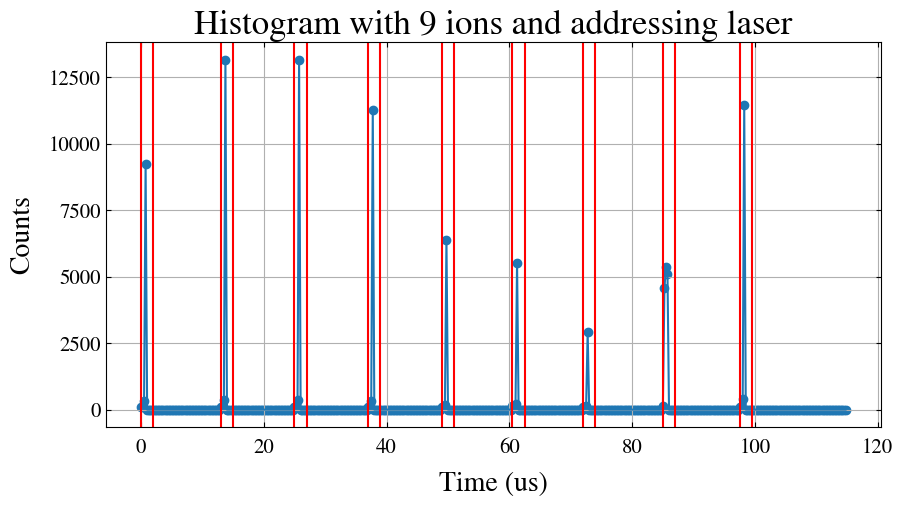

In [149]:
# Useful function for printing what is stored in the folder and display the files that are just created
def print_folder_content(folder):
    """Print filename and size of the files in the folder."""
    print("Filename            |       Size")
    print("--------------------+-----------")
    filenames = os.listdir(folder)
    for filename in [filenames[-1]] + filenames[:-1]:
        print("{:<20}|{:>8.1f} kB".format(filename, os.path.getsize(folder + os.sep + filename)/1024))

# Getting the current date and time
now = datetime.now()
# Extracting the date, hour, and minute
current_date = now.date()
current_hour = now.hour
current_minute = now.minute
# Converting to a char string
formatted_string = f"Date {current_date}, Time {current_hour}-{current_minute}"

# The Virtual Time Tagger is initialized similar to the physical one
tagger = TimeTagger.createTimeTaggerVirtual()
fig = plt.figure()

final_result = np.zeros(number)
final_hist = np.zeros(number_bins)

# The loop allows us to repeat the replay several times
for data in all_raw_data:
    binwidth = binwidth_corr
    n_bins = number   # Adjust number of bins as needed

    open_gate1 = TimeTagger.DelayedChannel(tagger=tagger, input_channel=trigger_channel, delay=Start_time1 * 1e6)
    open_gate_channel1 = open_gate1.getChannel()
    open_gate2 = TimeTagger.DelayedChannel(tagger=tagger, input_channel=trigger_channel, delay=Start_time2 * 1e6)
    open_gate_channel2 = open_gate2.getChannel()
    open_gate3 = TimeTagger.DelayedChannel(tagger=tagger, input_channel=trigger_channel, delay=Start_time3 * 1e6)
    open_gate_channel3 = open_gate3.getChannel()
    open_gate4 = TimeTagger.DelayedChannel(tagger=tagger, input_channel=trigger_channel, delay=Start_time4 * 1e6)
    open_gate_channel4 = open_gate4.getChannel()
    open_gate5 = TimeTagger.DelayedChannel(tagger=tagger, input_channel=trigger_channel, delay=Start_time5 * 1e6)
    open_gate_channel5 = open_gate5.getChannel()
    open_gate6 = TimeTagger.DelayedChannel(tagger=tagger, input_channel=trigger_channel, delay=Start_time6 * 1e6)
    open_gate_channel6 = open_gate6.getChannel()
    open_gate7 = TimeTagger.DelayedChannel(tagger=tagger, input_channel=trigger_channel, delay=Start_time7 * 1e6)
    open_gate_channel7 = open_gate7.getChannel()
    open_gate8 = TimeTagger.DelayedChannel(tagger=tagger, input_channel=trigger_channel, delay=Start_time8 * 1e6)
    open_gate_channel8 = open_gate8.getChannel()
    open_gate9 = TimeTagger.DelayedChannel(tagger=tagger, input_channel=trigger_channel, delay=Start_time9 * 1e6)
    open_gate_channel9 = open_gate9.getChannel()

    open_gate = TimeTagger.Combiner(tagger=tagger, channels=[open_gate_channel1,
                                                             open_gate_channel2,
                                                             open_gate_channel3,
                                                             open_gate_channel4,
                                                             open_gate_channel5,
                                                             open_gate_channel6,
                                                             open_gate_channel7,
                                                             open_gate_channel8,
                                                             open_gate_channel9])
    open_gate_channel = open_gate.getChannel()

    close_gate = TimeTagger.DelayedChannel(tagger=tagger, input_channel=open_gate_channel, delay=time_filtering)
    close_gate_channel = close_gate.getChannel()

    gated_PMT_channel1 = TimeTagger.GatedChannel(tagger=tagger, input_channel=PMT_channel1, gate_start_channel=open_gate_channel, gate_stop_channel=close_gate_channel)
    gated_PMT_channel2 = TimeTagger.GatedChannel(tagger=tagger, input_channel=PMT_channel2, gate_start_channel=open_gate_channel, gate_stop_channel=close_gate_channel)
    
    # hist = TimeTagger.Histogram(tagger=tagger, click_channel=PMT_channel1, start_channel = trigger_channel, binwidth = binwidth_hist, n_bins = number_bins)
    hist = TimeTagger.Histogram(tagger=tagger, click_channel=gated_PMT_channel2.getChannel(), start_channel = trigger_channel, binwidth = binwidth_hist, n_bins = number_bins)

    # corr = TimeTagger.Correlation(tagger=tagger, channel_1=gated_PMT_channel1.getChannel(), channel_2=gated_PMT_channel2.getChannel(), binwidth=binwidth, n_bins=n_bins)
    corr = TimeTagger.Correlation(tagger=tagger, channel_1=gated_PMT_channel1.getChannel(), channel_2=gated_PMT_channel2.getChannel(), binwidth=binwidth_corr, n_bins=n_bins)
    # measurement_time = int(0.001 * 3600 * 1e12)  # Adjust measurement time as needed

    # In general, the data are replayed at the same speed as they have been acquired. You can modify the speed by a factor or replay them as fast es possible by speed < 0
    tagger.setReplaySpeed(speed=-1)

    # Start the replay
    filename = g2_data_path + data
    tagger.replay(file=filename)

    while not tagger.waitForCompletion(timeout=-1):
        fig.clear()
        plt.plot(corr.getIndex(), corr.getData())
        plt.xlabel("Time difference [ps]")
        plt.ylabel("Counts")
        plt.pause(.1)

    # Extracting the date, hour, and minute
    current_date = now.date()
    current_hour = now.hour
    current_minute = now.minute
    # Converting to a char string
    formatted_string = f"Date {current_date}, Time {current_hour}-{current_minute}"
    print(formatted_string)

    # Get the correlation data
    hist_data = hist.getData()
    hist_index = hist.getIndex() / 1e6
    final_hist += hist_data
    np.save('hist_meas_'+formatted_string+'.npy', hist_index, hist_data)
    
    g2_data = corr.getData()
    index = corr.getIndex() / 1e6
    final_result += g2_data
    np.save('corr_meas_'+formatted_string+'.npy', index, g2_data)

    # Getting the current date and time
    now = datetime.now()

    # np.save('corr.getData_'+formatted_string+'.npy', corr.getData())
    # np.save('corr.getIndex_'+formatted_string+'.npy', corr.getIndex())

# Free the TimeTagger
TimeTagger.freeTimeTagger(tagger)

# Plot the g(2) function
np.save('data_final_corr_meas_'+formatted_string+'.npy', final_result)
np.save('index_final_corr_meas_'+formatted_string+'.npy', index)

plt.figure(figsize = (10, 5))
plt.plot(index, final_result)
plt.title("9 ions coincidence counts", fontdict={'size':20})
plt.xlabel("Delay (us)")
plt.ylabel("Counts")
plt.show()

title = "Histogram with 9 ions and addressing laser"
'''plt.plot'''
plt.figure(figsize = (10, 5))
plt.rc('font',family='STIXGeneral')
plt.scatter(hist_index, final_hist, c='C0')
plt.plot(hist_index, final_hist, c='C0')

plt.axvline(hist_index[np.where(hist_index == Start_time1)[0][0]], color='r')
print("Start time =", hist_index[np.where(hist_index == Start_time1)[0][0]], "us")
plt.axvline(hist_index[np.where(hist_index == End_time1)[0][0]], color='r')
print("End time =", hist_index[np.where(hist_index == End_time1)[0][0]], "us")

plt.axvline(hist_index[np.where(hist_index == Start_time2)[0][0]], color='r')
print("Start time =", hist_index[np.where(hist_index == Start_time2)[0][0]], "us")
plt.axvline(hist_index[np.where(hist_index == End_time2)[0][0]], color='r')
print("End time =", hist_index[np.where(hist_index == End_time2)[0][0]], "us")

plt.axvline(hist_index[np.where(hist_index == Start_time3)[0][0]], color='r')
print("Start time =", hist_index[np.where(hist_index == Start_time3)[0][0]], "us")
plt.axvline(hist_index[np.where(hist_index == End_time3)[0][0]], color='r')
print("End time =", hist_index[np.where(hist_index == End_time3)[0][0]], "us")

plt.axvline(hist_index[np.where(hist_index == Start_time4)[0][0]], color='r')
print("Start time =", hist_index[np.where(hist_index == Start_time4)[0][0]], "us")
plt.axvline(hist_index[np.where(hist_index == End_time4)[0][0]], color='r')
print("End time =", hist_index[np.where(hist_index == End_time4)[0][0]], "us")

plt.axvline(hist_index[np.where(hist_index == Start_time5)[0][0]], color='r')
print("Start time =", hist_index[np.where(hist_index == Start_time5)[0][0]], "us")
plt.axvline(hist_index[np.where(hist_index == End_time5)[0][0]], color='r')
print("End time =", hist_index[np.where(hist_index == End_time5)[0][0]], "us")

plt.axvline(hist_index[np.where(hist_index == Start_time6)[0][0]], color='r')
print("Start time =", hist_index[np.where(hist_index == Start_time6)[0][0]], "us")
plt.axvline(hist_index[np.where(hist_index == End_time6)[0][0]], color='r')
print("End time =", hist_index[np.where(hist_index == End_time6)[0][0]], "us")

plt.axvline(hist_index[np.where(hist_index == Start_time7)[0][0]], color='r')
print("Start time =", hist_index[np.where(hist_index == Start_time7)[0][0]], "us")
plt.axvline(hist_index[np.where(hist_index == End_time7)[0][0]], color='r')
print("End time =", hist_index[np.where(hist_index == End_time7)[0][0]], "us")

plt.axvline(hist_index[np.where(hist_index == Start_time8)[0][0]], color='r')
print("Start time =", hist_index[np.where(hist_index == Start_time8)[0][0]], "us")
plt.axvline(hist_index[np.where(hist_index == End_time8)[0][0]], color='r')
print("End time =", hist_index[np.where(hist_index == End_time8)[0][0]], "us")

plt.axvline(hist_index[np.where(hist_index == Start_time9)[0][0]], color='r')
print("Start time =", hist_index[np.where(hist_index == Start_time9)[0][0]], "us")
plt.axvline(hist_index[np.where(hist_index == End_time9)[0][0]], color='r')
print("End time =", hist_index[np.where(hist_index == End_time9)[0][0]], "us")

plt.title(title, fontdict={'family' : 'STIXGeneral', 'size':25})
plt.xlabel('Time (us)', fontdict={'family' : 'STIXGeneral', 'size':20})
plt.ylabel('Counts', fontdict={'family' : 'STIXGeneral', 'size':20})
# plt.ylim(0, np.max(counts) + 20)
plt.yticks(fontproperties='STIXGeneral', size=15)
plt.xticks(fontproperties='STIXGeneral', size=15)
plt.grid(True)
# plt.savefig('./'+file_name_PMT+' _data.jpg')
plt.show()

Start time = -74.0 us
End time = -68.0 us
Start time = -62.0 us
End time = -56.0 us
Start time = -50.0 us
End time = -44.0 us
Start time = -39.0 us
End time = -32.0 us
Start time = -27.0 us
End time = -21.0 us
Start time = -15.0 us
End time = -9.0 us
Start time = 9.0 us
End time = 15.0 us
Start time = 21.0 us
End time = 27.0 us
Start time = 33.0 us
End time = 39.0 us
Start time = 43.0 us
End time = 51.0 us
Start time = 56.0 us
End time = 62.0 us
Start time = 68.0 us
End time = 74.0 us


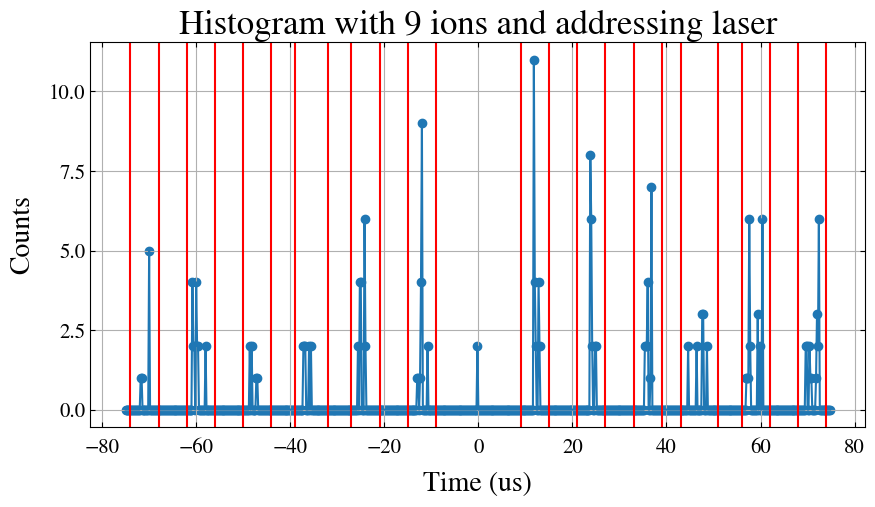

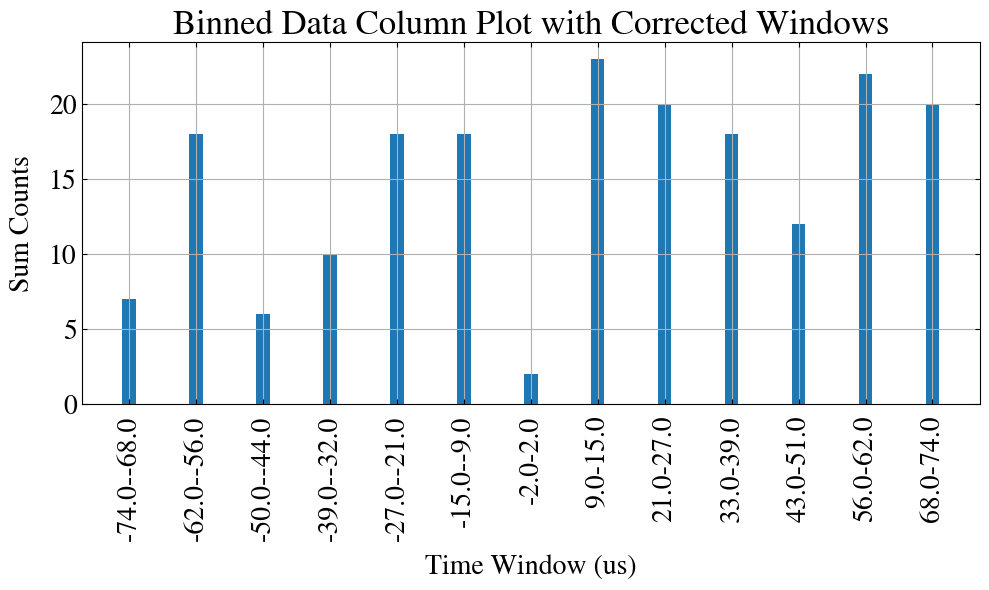

In [151]:
# Redefine the windows for binning based on the corrected start and end times
# Load the index and the data from the provided .npy files
# index_data = np.load('index_final_corr_meas_Date 2024-01-12, Time 14-50.npy')
# counts_data = np.load('data_final_corr_meas_Date 2024-01-12, Time 14-50.npy')
counts_data = final_result
index_data = index

bin_windows = [
    (-74.0, -68.0),
    (-62.0, -56.0),
    (-50.0, -44.0),
    (-39.0, -32.0),
    (-27.0, -21.0),
    (-15.0, -9.0),
    (-2.0, 2.0),
    (9.0, 15.0),
    (21.0, 27.0),
    (33.0, 39.0),
    (43.0, 51.0),
    (56.0, 62.0),
    (68.0, 74.0)
]

plt.figure(figsize = (10, 5))
plt.rc('font',family='STIXGeneral')
plt.plot(index_data, counts_data, c='C0')
plt.scatter(index_data, counts_data, c='C0')

plt.axvline(index_data[5], color='r')
print("Start time =", index_data[5], "us")
plt.axvline(index_data[35], color='r')
print("End time =", index_data[35], "us")

plt.axvline(index_data[65], color='r')
print("Start time =", index_data[65], "us")
plt.axvline(index_data[95], color='r')
print("End time =", index_data[95], "us")

plt.axvline(index_data[125], color='r')
print("Start time =", index_data[125], "us")
plt.axvline(index_data[155], color='r')
print("End time =", index_data[155], "us")

plt.axvline(index_data[180], color='r')
print("Start time =", index_data[180], "us")
plt.axvline(index_data[215], color='r')
print("End time =", index_data[215], "us")

plt.axvline(index_data[240], color='r')
print("Start time =", index_data[240], "us")
plt.axvline(index_data[270], color='r')
print("End time =", index_data[270], "us")

plt.axvline(index_data[300], color='r')
print("Start time =", index_data[300], "us")
plt.axvline(index_data[330], color='r')
print("End time =", index_data[330], "us")

plt.axvline(index_data[420], color='r')
print("Start time =", index_data[420], "us")
plt.axvline(index_data[450], color='r')
print("End time =", index_data[450], "us")

plt.axvline(index_data[480], color='r')
print("Start time =", index_data[480], "us")
plt.axvline(index_data[510], color='r')
print("End time =", index_data[510], "us")

plt.axvline(index_data[540], color='r')
print("Start time =", index_data[540], "us")
plt.axvline(index_data[570], color='r')
print("End time =", index_data[570], "us")

plt.axvline(index_data[590], color='r')
print("Start time =", index_data[590], "us")
plt.axvline(index_data[630], color='r')
print("End time =", index_data[630], "us")

plt.axvline(index_data[655], color='r')
print("Start time =", index_data[655], "us")
plt.axvline(index_data[685], color='r')
print("End time =", index_data[685], "us")

plt.axvline(index_data[715], color='r')
print("Start time =", index_data[715], "us")
plt.axvline(index_data[745], color='r')
print("End time =", index_data[745], "us")

plt.title(title, fontdict={'family' : 'STIXGeneral', 'size':25})
plt.xlabel('Time (us)', fontdict={'family' : 'STIXGeneral', 'size':20})
plt.ylabel('Counts', fontdict={'family' : 'STIXGeneral', 'size':20})
plt.yticks(fontproperties='STIXGeneral', size=15)
plt.xticks(fontproperties='STIXGeneral', size=15)
plt.grid(True)
plt.show()

# Re-bin the data according to the new specified windows
binned_counts = []

for start, end in bin_windows:
    # Find indices where the delay is within the current window (considering negative windows)
    indices_in_window = (index_data >= start) & (index_data <= end) if start < end else (index_data <= start) & (index_data >= end)
    # Sum the counts for these indices
    counts_sum = counts_data[indices_in_window].sum()
    binned_counts.append(counts_sum)

np.save("binned_counts_20240113", binned_counts)

# Re-plotting the binned data with the corrected windows
plt.figure(figsize=(10, 6))
x_labels = [f"{start}-{end}" for (start, end) in bin_windows]
plt.bar(x_labels, binned_counts, color='C0', width=0.2)
plt.xlabel('Time Window (us)')
plt.ylabel('Sum Counts')
plt.title('Binned Data Column Plot with Corrected Windows', fontdict={'family' : 'STIXGeneral', 'size':25})
plt.xticks(rotation=90)  # Rotate the labels to prevent overlap due to increased number of bins
plt.tight_layout()  # Adjust the plot to ensure everything fits without overlapping
plt.show()